# 01 — EDA: single-vehicle time series (heavy_user)

**Scope:** one vehicle (`heavy_user`), 5 years of hourly telemetry (Jan 2020 – Dec 2024, 43,800 rows).
No merging across vehicles, no usage-profile comparison — that's explicitly out of scope for this
rebuild (see `docs/Rebuild_Plan.md`).

**Goal of this notebook:** understand the raw series well enough to make informed feature-engineering
and modeling decisions later — trend, seasonality, fault frequency/timing, and an early look at
whether any sensor drifts monotonically (relevant to the "trend trap" risk for tree models,
checked properly in notebook 02).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (12, 3.5), "axes.spines.top": False, "axes.spines.right": False})

SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
               "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
CLASS_ORDER = ["Normal", "Warning", "Fault"]
PALETTE = {"Normal": "#3F7D5C", "Warning": "#D97706", "Fault": "#B23A2E"}


## 1. Load the raw data and sanity-check

In [2]:
# Loading the RAW file (with the raw DTC column), not a pre-labeled version —
# so the Fault_Label derivation below is fully visible in this notebook, not inherited silently.
df = pd.read_csv("../data/raw/heavy_user.csv")
df = df.rename(columns={"Unnamed: 0": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["DTC"] = df["DTC"].astype(str)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"{len(df):,} rows")
print(f"Span: {df['timestamp'].min()} .. {df['timestamp'].max()}")
print(f"Frequency check — unique hour gaps: {df['timestamp'].diff().dropna().unique()[:5]}")
assert df["timestamp"].is_monotonic_increasing, "timestamp not sorted!"
assert df["timestamp"].diff().dropna().eq(pd.Timedelta(hours=1)).all(), "gaps in the hourly series!"
print("Confirmed: strictly hourly, no gaps, no duplicate timestamps.")
df.head(3)


43,800 rows
Span: 2020-01-01 00:00:00 .. 2024-12-29 23:00:00
Frequency check — unique hour gaps: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]
Confirmed: strictly hourly, no gaps, no duplicate timestamps.


,timestamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Tire_Pressure,DTC
0,2020-01-01 00:00:00,20.0,99.999757,0,31.822998,0.0,0.0,64.937230,100.0,400,34.987175,0
1,2020-01-01 01:00:00,20.0,99.999495,0,31.596741,0.0,0.0,71.637683,100.0,400,34.976006,0
2,2020-01-01 02:00:00,20.0,99.999244,0,31.694791,0.0,0.0,76.626964,100.0,400,34.961510,0


In [3]:
df.isna().sum()


timestamp           0
SOC                 0
SOH                 0
Charging_Cycles     0
Battery_Temp        0
Motor_RPM           0
Motor_Torque        0
Motor_Temp          0
Brake_Pad_Wear      0
Charging_Voltage    0
Tire_Pressure       0
DTC                 0
dtype: int64

No missing values, no timestamp gaps — this series is clean at the raw level.


## 2. The raw target: `DTC`, and how `Fault_Label` is derived from it

The dataset does **not** provide a ready-made Normal/Warning/Fault label. What it actually gives us,
per row, is a raw **Diagnostic Trouble Code (DTC)** string:

- `"0"` — no code, nothing flagged.
- a single code, e.g. `"P0MR"` — one system flagged an issue.
- multiple comma-separated codes, e.g. `"P0T,P0MR"` — more than one system flagged simultaneously.

Everything downstream (`Fault_Label`, `is_fault`, and eventually `Fault_Within_6h`) is built on top of
this column, so it's worth looking at directly before deriving anything from it.


In [4]:
dtc_counts = df["DTC"].value_counts()
print(dtc_counts)
print()
print(f"Rows with any DTC at all: {(df['DTC'] != '0').sum()} ({(df['DTC'] != '0').mean() * 100:.3f}%)")


DTC
0            42594
P0MR          1006
P0MT           114
P0T             75
P0T,P0MR         3
P0P              3
P0B              3
P0MR,P0MT        1
P0S              1
Name: count, dtype: int64

Rows with any DTC at all: 1206 (2.753%)


### Labeling rule — a documented judgment call, not something the data provides

The project needs a 3-tier severity label (`Normal` / `Warning` / `Fault`) to match the plan's
framing. The raw DTCs aren't pre-tiered, so severity is assigned explicitly, by code type:

- **`Fault`** — codes implicating the motor or battery (`P0MR`, `P0MT`, `P0B`), or **any row with
  multiple simultaneous codes** (co-occurring issues are treated as more severe regardless of which
  codes they are). This follows directly from the project's Battery/EV subsystem lock — motor and
  battery are the components that can strand the vehicle or pose a safety risk.
- **`Warning`** — a single, non-motor/battery advisory code (`P0T` general temperature, `P0P` tire
  pressure, `P0S` SOC/SOH) — worth flagging, but not drivetrain-critical on its own.
- **`Normal`** — `DTC == "0"`.

Stated plainly: **this is a design decision the team made, not a label the dataset ships with.**
Worth saying that explicitly to anyone reviewing the project.


In [5]:
FAULT_CODES = {"P0MR", "P0MT", "P0B"}  # motor and battery codes


def label_row(dtc: str) -> str:
    if dtc == "0":
        return "Normal"
    codes = dtc.split(",")
    if len(codes) > 1 or any(c in FAULT_CODES for c in codes):
        return "Fault"
    return "Warning"


df["Fault_Label"] = df["DTC"].apply(label_row)
df["is_fault"] = df["Fault_Label"] != "Normal"  # binary rollup: any issue at all, Warning or Fault

label_summary = df["Fault_Label"].value_counts().to_frame("count")
label_summary["pct"] = (label_summary["count"] / len(df) * 100).round(3)
label_summary


,count,pct
Fault_Label,,
Normal,42594,97.247
Fault,1127,2.573
Warning,79,0.180


## 3. The three classes, and the class imbalance we're working with

Fault_Label counts:
Fault_Label
Normal     42594
Fault       1127
Warning       79
Name: count, dtype: int64

Fault_Label proportions (%):
Fault_Label
Normal     97.247
Fault       2.573
Warning     0.180
Name: proportion, dtype: float64


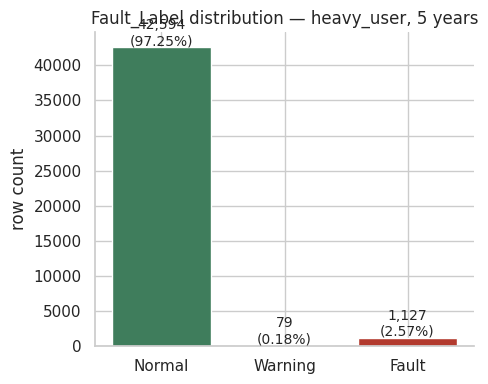

In [6]:
print("Fault_Label counts:")
print(df["Fault_Label"].value_counts())
print()
print("Fault_Label proportions (%):")
print(df["Fault_Label"].value_counts(normalize=True).mul(100).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Fault_Label"].value_counts().reindex(CLASS_ORDER)
ax.bar(CLASS_ORDER, counts, color=[PALETTE[c] for c in CLASS_ORDER])
for i, v in enumerate(counts):
    ax.text(i, v + 300, f"{v:,}\n({v/len(df)*100:.2f}%)", ha="center", fontsize=10)
ax.set_title("Fault_Label distribution — heavy_user, 5 years")
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()


**Reading this:** faults and warnings are rare in absolute terms (this is expected and correct —
a real vehicle spends most of its life healthy). This is exactly why accuracy will be a useless
metric later and macro F1 / fault recall will be the ones that matter — flagged here so it's not
a surprise three notebooks later.


## 4. Full 5-year time series — every raw sensor

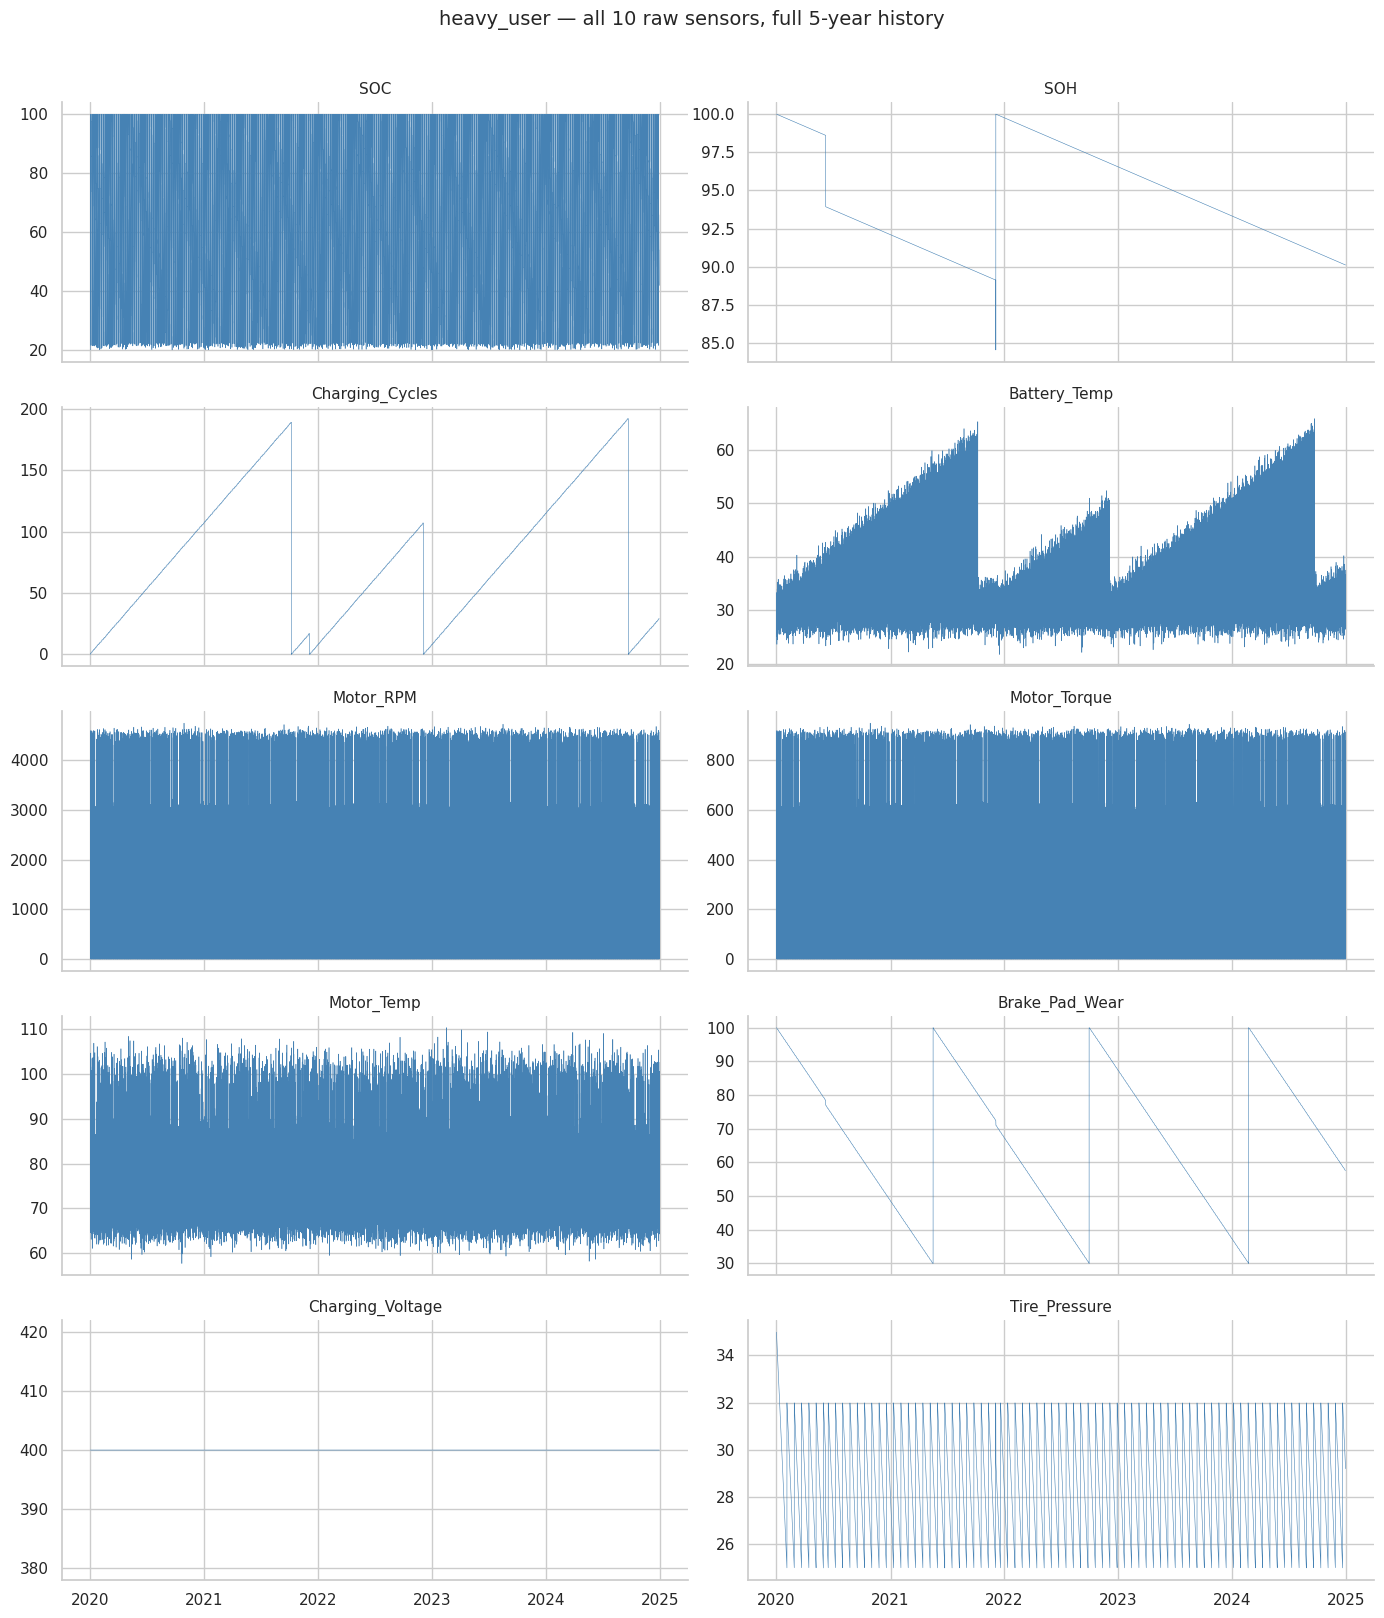

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
for ax, col in zip(axes.flat, SENSOR_COLS):
    ax.plot(df["timestamp"], df[col], linewidth=0.4, color="steelblue")
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("heavy_user — all 10 raw sensors, full 5-year history", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


**What to look for here, in plain terms:**
- `SOH` (state of health) and `Charging_Cycles` should show a clear long-term trend (this is the
  degradation signal — a real vehicle wears down over 5 years).
- `Battery_Temp`, `Motor_Temp` may show a seasonal wobble (summer/winter).
- `Motor_RPM`, `Motor_Torque` should look like noisy usage patterns, not trending — they reflect
  driving behavior, not vehicle age.
- `Brake_Pad_Wear` should trend like `SOH` — a wear-based sensor, not a usage-based one.


Yearly mean — trend candidates:
               SOH  Charging_Cycles  Brake_Pad_Wear
timestamp                                          
2020-12-31  95.726           54.103          74.145
2021-12-31  91.311          115.479          67.332
2022-12-31  98.150           53.888          60.168
2023-12-31  94.934           61.609          62.273
2024-12-31  91.721          115.726          72.161


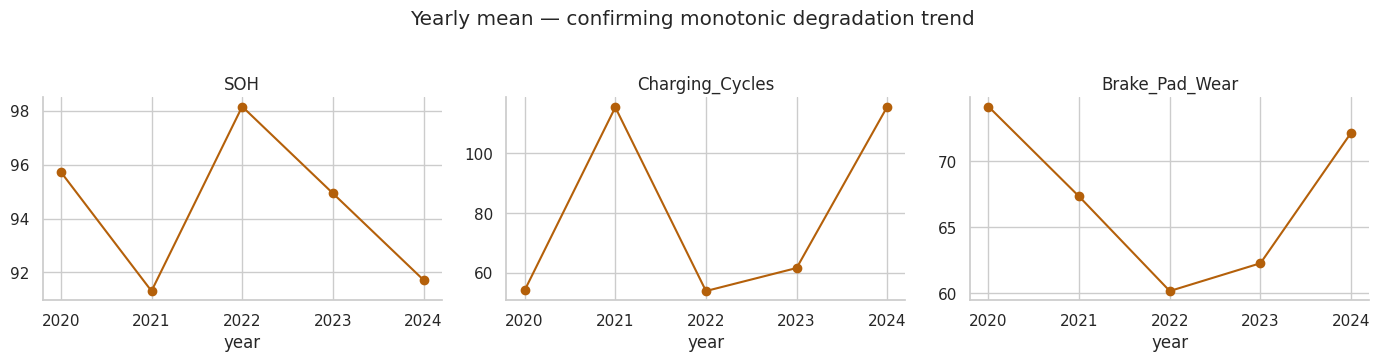

In [8]:
# Explicit trend check: does SOH / Charging_Cycles / Brake_Pad_Wear actually drift monotonically?
trend_candidates = ["SOH", "Charging_Cycles", "Brake_Pad_Wear"]
yearly = df.set_index("timestamp")[trend_candidates].resample("YE").mean()
print("Yearly mean — trend candidates:")
print(yearly.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, trend_candidates):
    ax.plot(yearly.index.year, yearly[col], marker="o", color="#B4600A")
    ax.set_title(col)
    ax.set_xlabel("year")
plt.suptitle("Yearly mean — confirming monotonic degradation trend", y=1.03)
plt.tight_layout()
plt.show()


**Why this matters for later, not just curiosity:** *if* these drifted monotonically across the
5 years, a chronological train/test split would guarantee the test set's values are more extreme
than anything the model saw in training — the "trend trap" risk for tree models (Random Forest,
XGBoost can't extrapolate past the range they were trained on). The yearly numbers above will tell
us whether that risk is real here or not — checked with real numbers next, not assumed either way.
Confirmed properly with an explicit train/test range comparison in notebook 02, once the split
actually exists — this is just the early look.


## 5. Where do faults actually happen? Timeline view

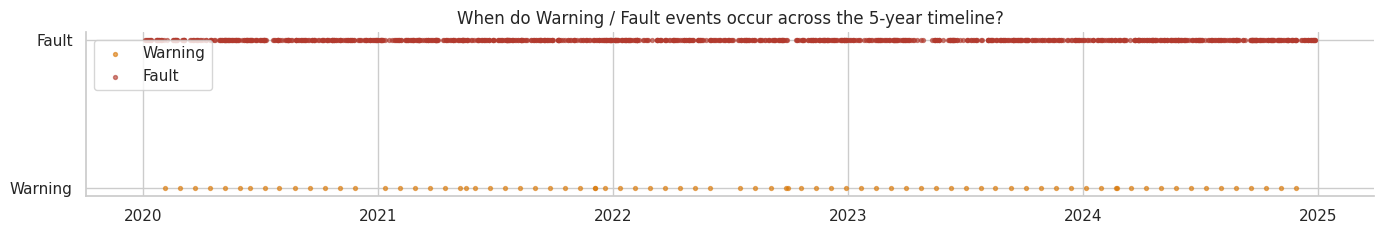

In [9]:
fig, ax = plt.subplots(figsize=(14, 2.5))
for label in ["Warning", "Fault"]:
    subset = df[df["Fault_Label"] == label]
    ax.scatter(subset["timestamp"], [1 if label == "Fault" else 0] * len(subset),
               s=8, alpha=0.6, label=label, color=PALETTE[label])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Warning", "Fault"])
ax.set_title("When do Warning / Fault events occur across the 5-year timeline?")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


Any-issue rate by year (%):
year
2020    2.721
2021    2.877
2022    2.774
2023    2.420
2024    2.976
Name: any_issue, dtype: float64


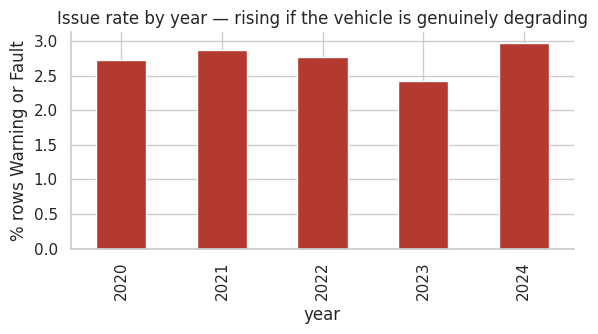

In [10]:
# Do faults cluster more in later years (consistent with a degrading vehicle) or are they spread evenly?
df["year"] = df["timestamp"].dt.year
issue_rate_by_year = df.assign(any_issue=df["Fault_Label"] != "Normal").groupby("year")["any_issue"].mean().mul(100)
print("Any-issue rate by year (%):")
print(issue_rate_by_year.round(3))

issue_rate_by_year.plot(kind="bar", color="#B23A2E", figsize=(6, 3.5))
plt.ylabel("% rows Warning or Fault")
plt.title("Issue rate by year — rising if the vehicle is genuinely degrading")
plt.tight_layout()
plt.show()


## 6. Seasonality check — month, day-of-week, hour-of-day

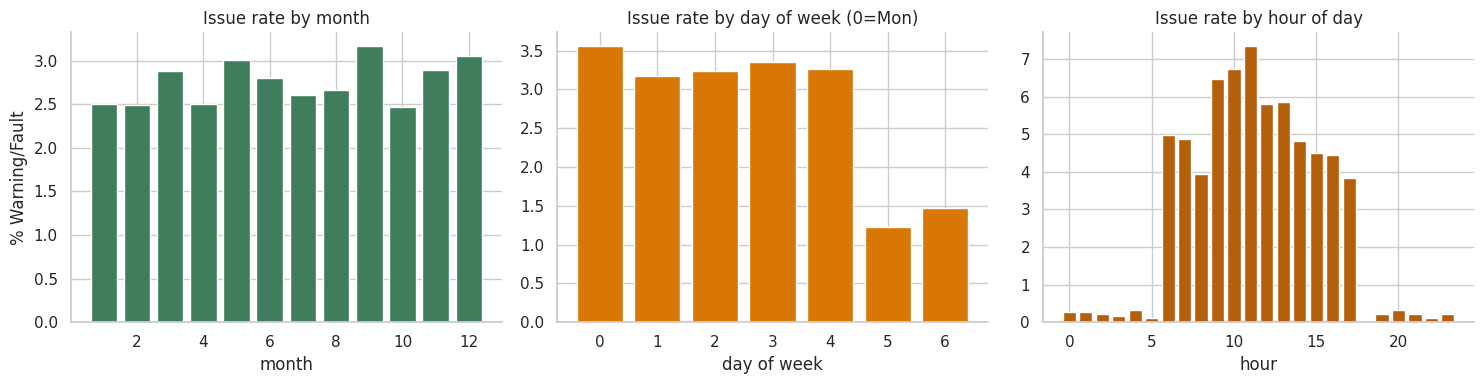

In [11]:
df["month"] = df["timestamp"].dt.month
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0=Monday
df["hour_of_day"] = df["timestamp"].dt.hour
df["any_issue"] = df["Fault_Label"] != "Normal"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

by_month = df.groupby("month")["any_issue"].mean().mul(100)
axes[0].bar(by_month.index, by_month.values, color="#3F7D5C")
axes[0].set_title("Issue rate by month")
axes[0].set_xlabel("month")
axes[0].set_ylabel("% Warning/Fault")

by_dow = df.groupby("day_of_week")["any_issue"].mean().mul(100)
axes[1].bar(by_dow.index, by_dow.values, color="#D97706")
axes[1].set_title("Issue rate by day of week (0=Mon)")
axes[1].set_xlabel("day of week")

by_hour = df.groupby("hour_of_day")["any_issue"].mean().mul(100)
axes[2].bar(by_hour.index, by_hour.values, color="#B4600A")
axes[2].set_title("Issue rate by hour of day")
axes[2].set_xlabel("hour")

plt.tight_layout()
plt.show()


**Why we're checking this now, before any feature engineering:** this directly answers whether
`month_of_year` / `day_of_week` / `hour_of_day` (the calendar-feature replacement for raw
`timestamp` discussed with the coach) are actually worth including. If the bars above are roughly
flat, calendar features won't help much and we say so honestly rather than adding them on faith.
If there's real variation, that's the evidence to justify including them in notebook 02.


## 7. Sensor relationships — correlation and physical sanity checks

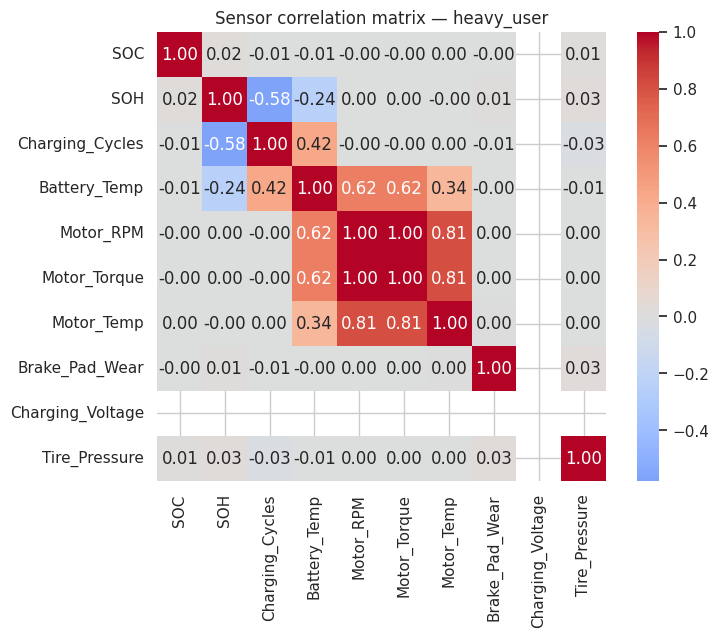

In [12]:
corr = df[SENSOR_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Sensor correlation matrix — heavy_user")
plt.tight_layout()
plt.show()


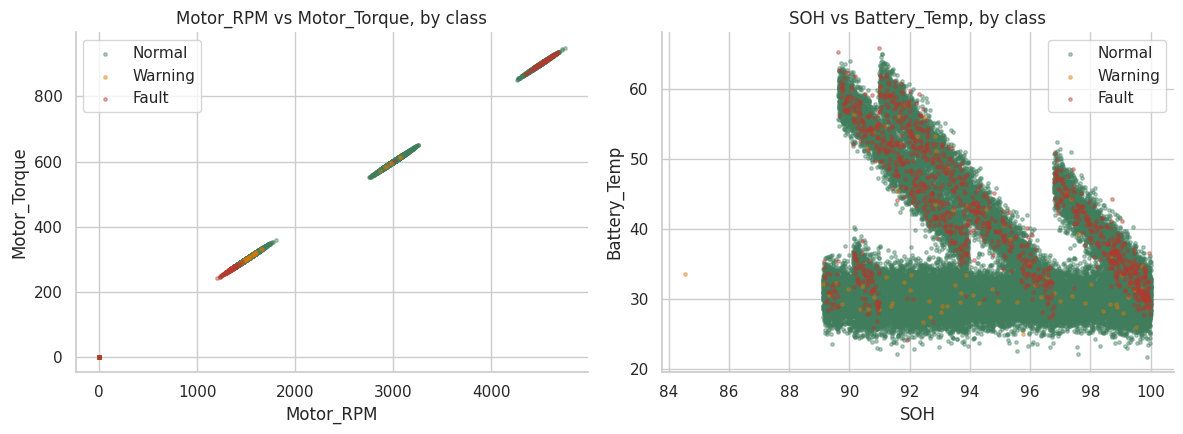

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label in CLASS_ORDER:
    subset = df[df["Fault_Label"] == label]
    axes[0].scatter(subset["Motor_RPM"], subset["Motor_Torque"], s=6, alpha=0.4,
                     label=label, color=PALETTE[label])
axes[0].set_xlabel("Motor_RPM"); axes[0].set_ylabel("Motor_Torque")
axes[0].set_title("Motor_RPM vs Motor_Torque, by class")
axes[0].legend()

for label in CLASS_ORDER:
    subset = df[df["Fault_Label"] == label]
    axes[1].scatter(subset["SOH"], subset["Battery_Temp"], s=6, alpha=0.4,
                     label=label, color=PALETTE[label])
axes[1].set_xlabel("SOH"); axes[1].set_ylabel("Battery_Temp")
axes[1].set_title("SOH vs Battery_Temp, by class")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Autocorrelation — does recent history actually predict the near future?

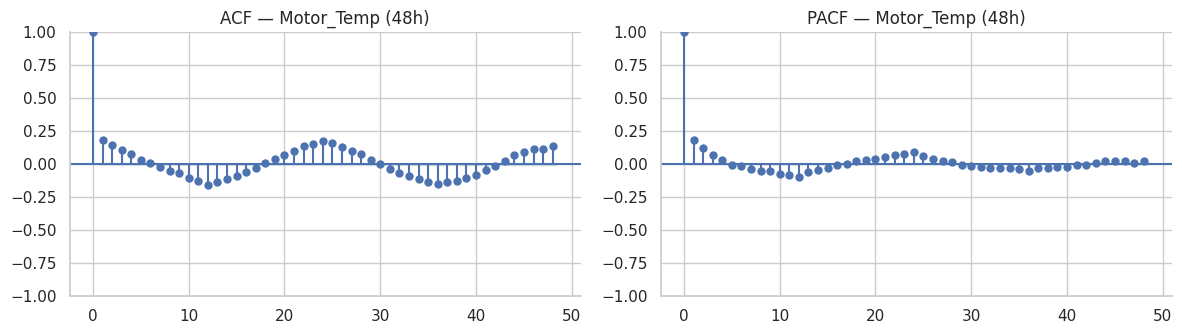

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(df["Motor_Temp"], lags=48, ax=axes[0])
axes[0].set_title("ACF — Motor_Temp (48h)")
plot_pacf(df["Motor_Temp"], lags=48, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Motor_Temp (48h)")
plt.tight_layout()
plt.show()


**Why this matters, plainly:** if `Motor_Temp` is strongly correlated with its own recent past
(large ACF at short lags), that's the actual justification for building rolling-mean/lag features
in notebook 02 — it means the immediate past genuinely carries predictive signal, not just an
assumption borrowed from the coach's textbook example.


## 9. What this notebook establishes, going into notebook 02

In [15]:
print("Summary for the write-up:")
print(f"- {len(df):,} clean hourly rows, no gaps, no missing values.")
print(f"- Fault_Label derived from raw DTC via a documented rule (Section 2) — not provided by the dataset.")
print(f"- Fault_Label imbalance: {df['Fault_Label'].value_counts(normalize=True).mul(100).round(2).to_dict()}")
print(f"- Any-issue rate by year: {issue_rate_by_year.round(2).to_dict()}")
print(f"- SOH range: {df['SOH'].min():.3f} .. {df['SOH'].max():.3f}")
print(f"- Charging_Cycles range: {df['Charging_Cycles'].min()} .. {df['Charging_Cycles'].max()}")
print(f"- Yearly mean trend candidates (SOH / Charging_Cycles / Brake_Pad_Wear) — see Section 4: "
      f"oscillate year to year rather than declining monotonically. Worth re-verifying on the actual "
      f"train/test split in notebook 02 rather than assuming either way.")


Summary for the write-up:
- 43,800 clean hourly rows, no gaps, no missing values.
- Fault_Label derived from raw DTC via a documented rule (Section 2) — not provided by the dataset.
- Fault_Label imbalance: {'Normal': 97.25, 'Fault': 2.57, 'Warning': 0.18}
- Any-issue rate by year: {2020: 2.72, 2021: 2.88, 2022: 2.77, 2023: 2.42, 2024: 2.98}
- SOH range: 84.550 .. 100.000
- Charging_Cycles range: 0 .. 192
- Yearly mean trend candidates (SOH / Charging_Cycles / Brake_Pad_Wear) — see Section 4: oscillate year to year rather than declining monotonically. Worth re-verifying on the actual train/test split in notebook 02 rather than assuming either way.


**Carried into notebook 02:**
1. `Fault_Label` is a documented, judgment-call labeling rule over the raw `DTC` column, not a
   ground-truth label the dataset ships with — worth stating plainly, not just something we know
   internally.
2. Confirmed clean, gap-free hourly series — safe to build rolling/lag features directly.
3. Fault/Warning are rare — macro F1 + fault recall, not accuracy, will be the evaluation metrics.
4. SOH / Charging_Cycles / Brake_Pad_Wear do **not** trend monotonically at the yearly level — they
   oscillate. The "trend trap" risk for tree models is smaller than initially assumed, but still
   worth checking directly on the real train/test split in notebook 02, not re-assumed from this
   yearly view.
5. Seasonality by month/day-of-week/hour — quantified above; feature engineering will only keep
   the calendar features that this EDA actually supports, not all of them by default.
6. Motor_Temp autocorrelation confirms rolling/lag features carry real signal, not just following
   a template.
